# Predicting LLM Activations with QA-Emb

This notebook extends the QA-Emb paper (Benara et al., 2024) to predict **LLM internal activations** instead of fMRI voxels. Uses the same fMRI story corpus (OpenNeuro ds003020) for direct comparison with brain results.

**Pipeline:**
1. Prepare text n-grams from the full fMRI story corpus (same stories used in the paper)
2. Extract Llama 3-8B hidden states at layers 0 (first), 16 (middle), 31 (last)
3. Compute QA-Emb: answer 674 yes/no questions per n-gram
4. PCA on activations → top 100 components (matching fMRI paper)
5. Ridge regression: QA-Emb → PCA components (story-based train/test split)
6. Evaluate: can interpretable yes/no questions predict LLM representations?

## 1. Setup & Installs

In [1]:
!pip install -q transformers accelerate datasets scikit-learn matplotlib numpy torch

In [2]:
import json
import os
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from datasets import load_dataset
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name()}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA H200 NVL
Memory: 150.1 GB


## 2. Configure SCF Paths

`QA_CACHE_ROOT` points at the paper authors' precomputed QA-Emb cache (read-only). `CACHE_DIR` is where this notebook writes activation checkpoints. Both live under `/scratch/users/arihant_kaul/` because the `accounts` filesystem has only a 10 GB user quota and the activation cache alone will be ~9 GB.

In [3]:
QA_CACHE_ROOT = '/scratch/users/arihant_kaul/fmri_cached_qa_features'
CACHE_DIR = '/scratch/users/arihant_kaul/qa_emb_activations'
os.makedirs(CACHE_DIR, exist_ok=True)

assert os.path.isdir(QA_CACHE_ROOT), f'QA cache missing: {QA_CACHE_ROOT}'
print(f'QA cache:    {QA_CACHE_ROOT}')
print(f'Write cache: {CACHE_DIR}')

QA cache:    /scratch/users/arihant_kaul/fmri_cached_qa_features
Write cache: /scratch/users/arihant_kaul/qa_emb_activations


## 3. Load the 674 Questions

Read the question list from the train metadata pickle's `columns` field. This is the source of truth: it guarantees `QUESTIONS[i]` is the question that produced QA-Emb column `i`, with no risk of column-order drift.

In [4]:
import pickle

LLAMA_FOLDER = f'{QA_CACHE_ROOT}/meta-llama___Meta-Llama-3-8B-Instruct'

with open(f'{LLAMA_FOLDER}/v3_boostexamples_train_metadata.pkl', 'rb') as f:
    meta_train = pickle.load(f)
QUESTIONS = list(meta_train['columns'])
assert len(QUESTIONS) == 674

print(f'Loaded {len(QUESTIONS)} questions')
print(f'Examples: {QUESTIONS[:3]}')

Loaded 674 questions
Examples: ['Does the input contain a measurement?', 'Does the input contain a number?', 'Does the input contain a question?']


In [5]:
with open(f'{LLAMA_FOLDER}/v3_boostexamples_test_metadata.pkl', 'rb') as f:
    meta_test = pickle.load(f)

train_ngrams = list(meta_train['index'])
test_ngrams  = list(meta_test['index'])
ngrams = train_ngrams + test_ngrams

assert len(train_ngrams) == 184564, len(train_ngrams)
assert len(test_ngrams)  == 5951,   len(test_ngrams)

print(f'Train: {len(train_ngrams)}, Test: {len(test_ngrams)}, Total: {len(ngrams)}')
print('Example train n-grams:')
for s in train_ngrams[:3]:
    print(f'  "{s}"')

Train: 184564, Test: 5951, Total: 190515
Example train n-grams:
  ""
  "for"
  "for the"


## 5. Load Llama 3-8B-Instruct

We load the model in native float16 (no quantization) for extracting exact hidden states.

In [6]:
from huggingface_hub import login

_token = os.environ.get('HF_TOKEN') or os.environ.get('HUGGING_FACE_HUB_TOKEN')
if _token:
    login(token=_token, add_to_git_credential=False)
else:
    login()  # interactive fallback (Colab/local)


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [7]:
MODEL_NAME = 'meta-llama/Meta-Llama-3-8B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto',
)
model.eval()

num_layers = model.config.num_hidden_layers
hidden_size = model.config.hidden_size
print(f'Model loaded: {num_layers} layers, hidden size {hidden_size}')
print(f'Layers to extract: 0 (first), {num_layers // 2} (middle), {num_layers - 1} (last)')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded: 32 layers, hidden size 4096
Layers to extract: 0 (first), 16 (middle), 31 (last)


## 6. Extract Activations

For each n-gram, we extract the **last token's hidden state** at layers 0, 16, and 31. Batch size is 8 to avoid GPU OOM (storing all 33 layer hidden states is memory-intensive). Checkpoints to `CACHE_DIR` every 512 samples.

In [8]:
LAYER_INDICES = [0, num_layers // 2, num_layers - 1]  # [0, 16, 31]
BATCH_SIZE_ACT = 8  # reduced from 32 to avoid OOM with output_hidden_states
CHECKPOINT_EVERY = 512

cache_file = os.path.join(CACHE_DIR, 'activations_full.npz')
partial_file = os.path.join(CACHE_DIR, 'activations_full_partial.npz')

if os.path.exists(cache_file):
    print('Loading cached activations...')
    cached = np.load(cache_file)
    activations = {int(k.split('_')[1]): cached[k] for k in cached.files}
else:
    n_total = len(ngrams)
    torch.cuda.empty_cache()

    # Check for partial progress
    if os.path.exists(partial_file):
        cached = np.load(partial_file)
        start = int(cached['progress'])
        acts = {int(k.split('_')[1]): cached[k] for k in cached.files if k != 'progress'}
        for l in LAYER_INDICES:
            full = np.zeros((n_total, hidden_size), dtype=np.float32)
            full[:start] = acts[l]
            acts[l] = full
        print(f'Resuming activation extraction from sample {start}/{n_total}')
    else:
        start = 0
        acts = {l: np.zeros((n_total, hidden_size), dtype=np.float32) for l in LAYER_INDICES}

    for i in tqdm(range(start, n_total, BATCH_SIZE_ACT), desc='Extracting activations'):
        batch = ngrams[i:i + BATCH_SIZE_ACT]
        inputs = tokenizer(
            batch, return_tensors='pt', padding=True,
            truncation=True, max_length=128,
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        hidden_states = outputs.hidden_states
        seq_lengths = inputs['attention_mask'].sum(dim=1) - 1

        for l in LAYER_INDICES:
            h = hidden_states[l + 1][torch.arange(len(batch)), seq_lengths]
            acts[l][i:i + len(batch)] = h.cpu().float().numpy()

        # Free GPU memory
        del outputs, hidden_states, inputs
        torch.cuda.empty_cache()

        # Periodic checkpoint
        done = i + len(batch)
        if done % CHECKPOINT_EVERY < BATCH_SIZE_ACT or done == n_total:
            save_dict = {f'layer_{l}': acts[l][:done] for l in LAYER_INDICES}
            save_dict['progress'] = np.array(done)
            np.savez(partial_file, **save_dict)

    activations = acts
    np.savez(cache_file, **{f'layer_{l}': v for l, v in activations.items()})
    if os.path.exists(partial_file):
        os.remove(partial_file)
    print('Activations saved to final cache.')

for l in LAYER_INDICES:
    print(f'Layer {l}: shape {activations[l].shape}')

Loading cached activations...


Layer 0: shape (190515, 4096)
Layer 16: shape (190515, 4096)
Layer 31: shape (190515, 4096)


## 7. Load Precomputed QA-Emb (Llama-3-8B)

Single-model setup: load the Llama-3-8B-Instruct answers from the precomputed cache, concatenate train + test, and cast bool → float32. No ensemble, no API calls.

In [9]:
qa_train = np.load(f'{LLAMA_FOLDER}/v3_boostexamples_answers_train_numpy.npz')['arr_0']
qa_test  = np.load(f'{LLAMA_FOLDER}/v3_boostexamples_answers_test_numpy.npz')['arr_0']

assert qa_train.shape == (184564, 674), qa_train.shape
assert qa_test.shape  == (5951, 674),   qa_test.shape

qa_emb = np.concatenate([qa_train, qa_test], axis=0).astype(np.float32)
del qa_train, qa_test

N_QUESTIONS = qa_emb.shape[1]
print(f'QA-Emb shape: {qa_emb.shape}')
print(f'Mean yes-rate: {qa_emb.mean():.3f}')
print(f'Per-question yes-rate range: [{qa_emb.mean(axis=0).min():.3f}, {qa_emb.mean(axis=0).max():.3f}]')

QA-Emb shape: (190515, 674)
Mean yes-rate: 0.305
Per-question yes-rate range: [0.001, 0.993]


## 8. PCA on Activations

For each layer, we run PCA on the activation matrix and extract the top 100 components (matching the fMRI paper, now justified with ~27k samples). PCA is fit on training data only to avoid leakage.

Train: 184564, Test: 5951 (story-based split)


Layer 0: PCA shape (190515, 100), variance explained (100 PCs) = 0.470


Layer 16: PCA shape (190515, 100), variance explained (100 PCs) = 0.691


Layer 31: PCA shape (190515, 100), variance explained (100 PCs) = 0.600


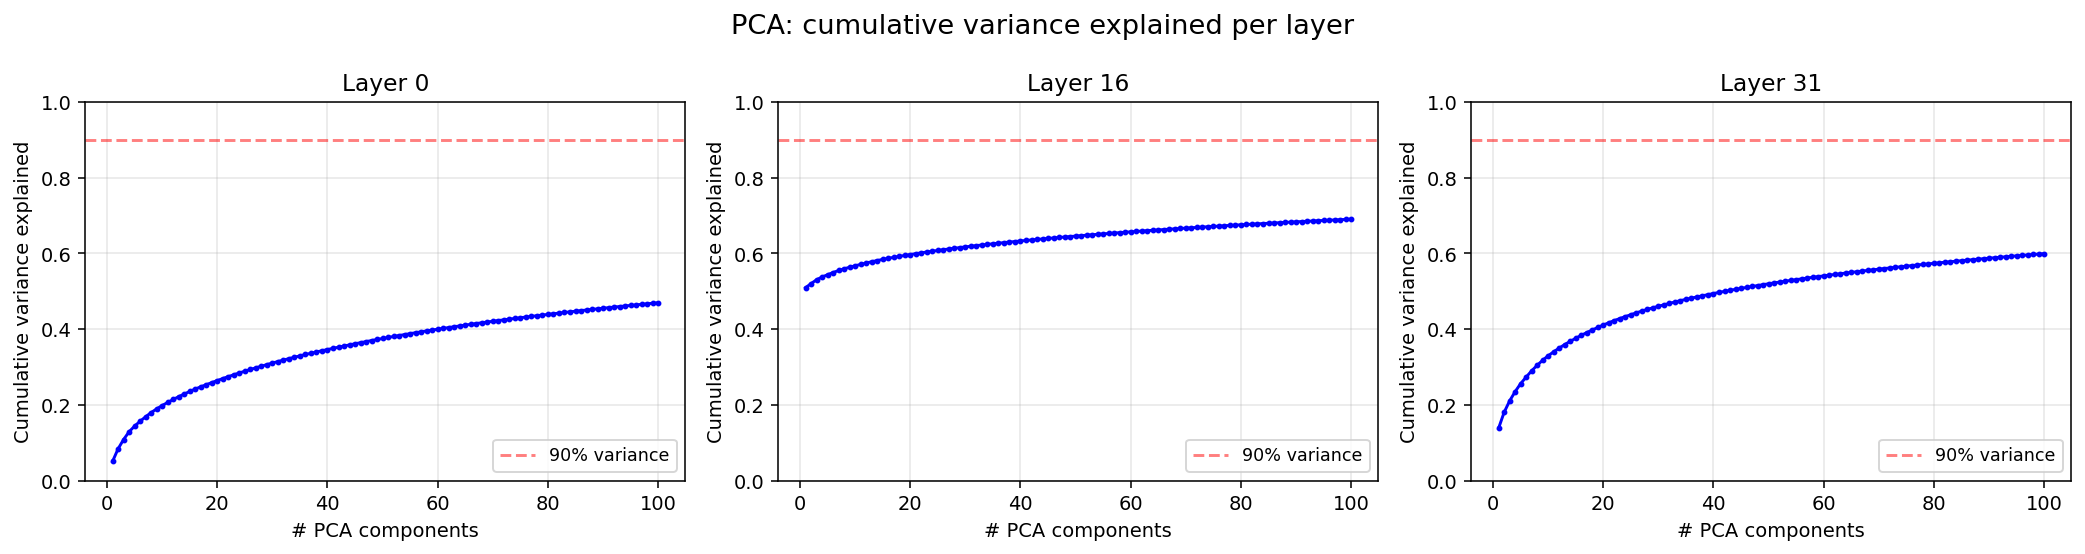

In [10]:
N_PCA_COMPONENTS = 100

# Story-based train/test split (matching the fMRI paper)
n_train = len(train_ngrams)
n_test = len(test_ngrams)
train_idx = np.arange(n_train)
test_idx = np.arange(n_train, n_train + n_test)
print(f'Train: {n_train}, Test: {n_test} (story-based split)')

pca_models = {}
pca_activations = {}

fig, axes = plt.subplots(1, len(LAYER_INDICES), figsize=(15, 4))

for ax_idx, layer_idx in enumerate(LAYER_INDICES):
    # Fit PCA on training data only
    pca = PCA(n_components=N_PCA_COMPONENTS)
    pca.fit(activations[layer_idx][train_idx])

    # Transform both train and test
    pca_act = pca.transform(activations[layer_idx])

    pca_models[layer_idx] = pca
    pca_activations[layer_idx] = pca_act

    cumvar = np.cumsum(pca.explained_variance_ratio_)
    axes[ax_idx].plot(range(1, N_PCA_COMPONENTS + 1), cumvar, 'b-o', markersize=2)
    axes[ax_idx].set_xlabel('Number of components')
    axes[ax_idx].set_ylabel('Cumulative variance explained')
    axes[ax_idx].set_title(f'Layer {layer_idx}')
    axes[ax_idx].axhline(y=0.9, color='r', linestyle='--', alpha=0.5)
    axes[ax_idx].set_ylim(0, 1)

    print(f'Layer {layer_idx}: PCA shape {pca_act.shape}, '
          f'variance explained ({N_PCA_COMPONENTS} PCs) = {cumvar[-1]:.3f}')

plt.suptitle('PCA Variance Explained per Layer', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Ridge Regression: QA-Emb → PCA Components

For each layer, we fit a ridge regression from the 674-dim QA-Emb to the 100-dim PCA activation space. We use `RidgeCV` with built-in cross-validation for alpha selection. Train/test split is story-based (matching the fMRI paper).

In [11]:
ALPHAS = np.logspace(-1, 4, 20)  # Ridge regularization candidates

X_train = qa_emb[train_idx]
X_test = qa_emb[test_idx]

ridge_cache = os.path.join(CACHE_DIR, 'ridge_results.npz')

if os.path.exists(ridge_cache):
    print(f'Loading cached Ridge results from {ridge_cache}')
    cached = np.load(ridge_cache, allow_pickle=True)
    results = cached['results'].item()
    for layer_idx in LAYER_INDICES:
        r = results[layer_idx]
        print(f'Layer {layer_idx}: mean r = {r["mean_corr"]:.4f}, '
              f'best alpha = {r["best_alpha"]:.2f}, '
              f'top-5 corrs = {np.sort(r["correlations"])[::-1][:5].round(3)}')
else:
    results = {}
    for layer_idx in LAYER_INDICES:
        Y_train = pca_activations[layer_idx][train_idx]
        Y_test = pca_activations[layer_idx][test_idx]

        ridge = RidgeCV(alphas=ALPHAS, scoring='neg_mean_squared_error')
        ridge.fit(X_train, Y_train)

        Y_pred = ridge.predict(X_test)

        correlations = []
        for comp in range(N_PCA_COMPONENTS):
            if np.std(Y_test[:, comp]) > 1e-10 and np.std(Y_pred[:, comp]) > 1e-10:
                r, _ = pearsonr(Y_test[:, comp], Y_pred[:, comp])
                correlations.append(r)
            else:
                correlations.append(0.0)
        correlations = np.array(correlations)

        results[layer_idx] = {
            'coef': ridge.coef_,
            'correlations': correlations,
            'mean_corr': float(np.mean(correlations)),
            'best_alpha': float(ridge.alpha_),
            'Y_pred': Y_pred,
            'Y_test': Y_test,
        }

        print(f'Layer {layer_idx}: mean r = {np.mean(correlations):.4f}, '
              f'best alpha = {ridge.alpha_:.2f}, '
              f'top-5 corrs = {np.sort(correlations)[::-1][:5].round(3)}')

    np.savez(ridge_cache, results=results)
    print(f'Saved Ridge results to {ridge_cache}')


Loading cached Ridge results from /scratch/users/arihant_kaul/qa_emb_activations/ridge_results.npz


Layer 0: mean r = 0.1797, best alpha = 263.67, top-5 corrs = [0.484 0.41  0.39  0.297 0.278]
Layer 16: mean r = 0.3704, best alpha = 23.36, top-5 corrs = [0.694 0.646 0.628 0.577 0.562]
Layer 31: mean r = 0.4059, best alpha = 483.29, top-5 corrs = [0.683 0.65  0.599 0.579 0.555]


## 10. Evaluation & Visualization

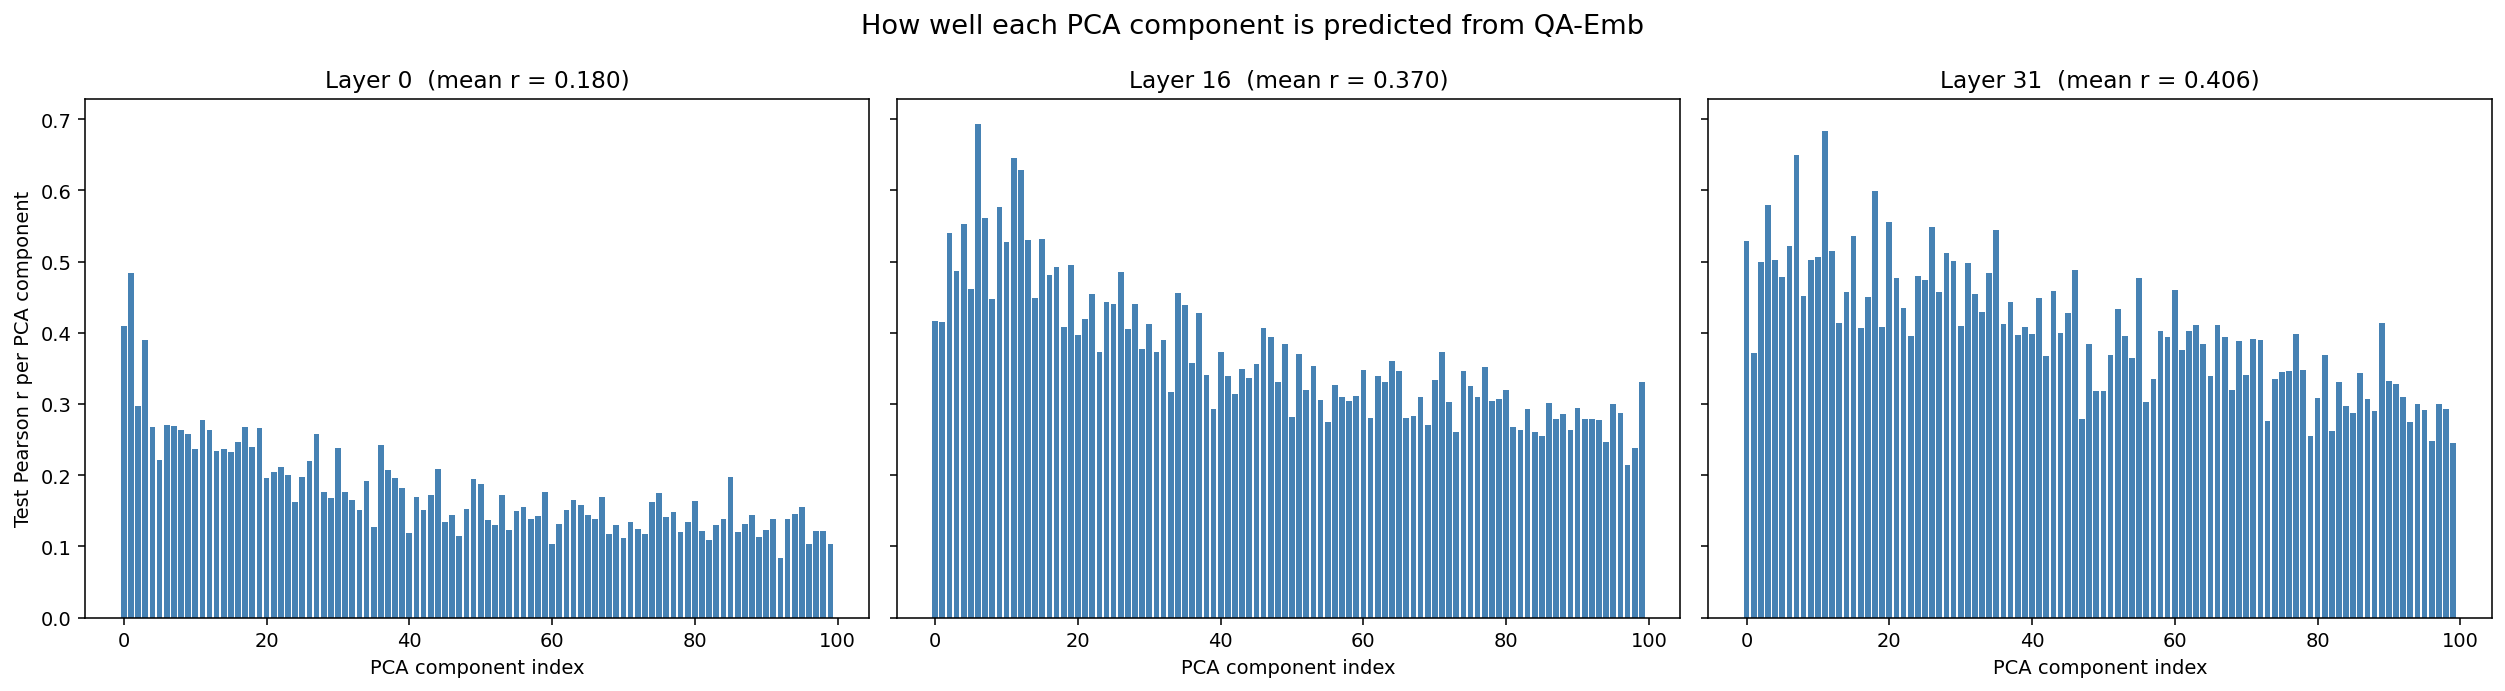

In [12]:
# --- A: Per-component correlation (PCA space) ---
fig, axes = plt.subplots(1, len(LAYER_INDICES), figsize=(18, 5), sharey=True)

for ax_idx, layer_idx in enumerate(LAYER_INDICES):
    corrs = results[layer_idx]['correlations']
    colors = ['steelblue' if c > 0 else 'salmon' for c in corrs]
    axes[ax_idx].bar(range(N_PCA_COMPONENTS), corrs, color=colors, width=0.8)
    axes[ax_idx].axhline(y=0, color='black', linewidth=0.5)
    axes[ax_idx].set_xlabel('PCA Component index')
    axes[ax_idx].set_title(
        f'Layer {layer_idx}  (mean r = {results[layer_idx]["mean_corr"]:.4f})'
    )
    if ax_idx == 0:
        axes[ax_idx].set_ylabel('Test Pearson correlation\n(QA-Emb -> PCA component)')

plt.suptitle('Per-Component Test Correlation in PCA Space (100 components)', fontsize=14)
plt.tight_layout()
plt.show()


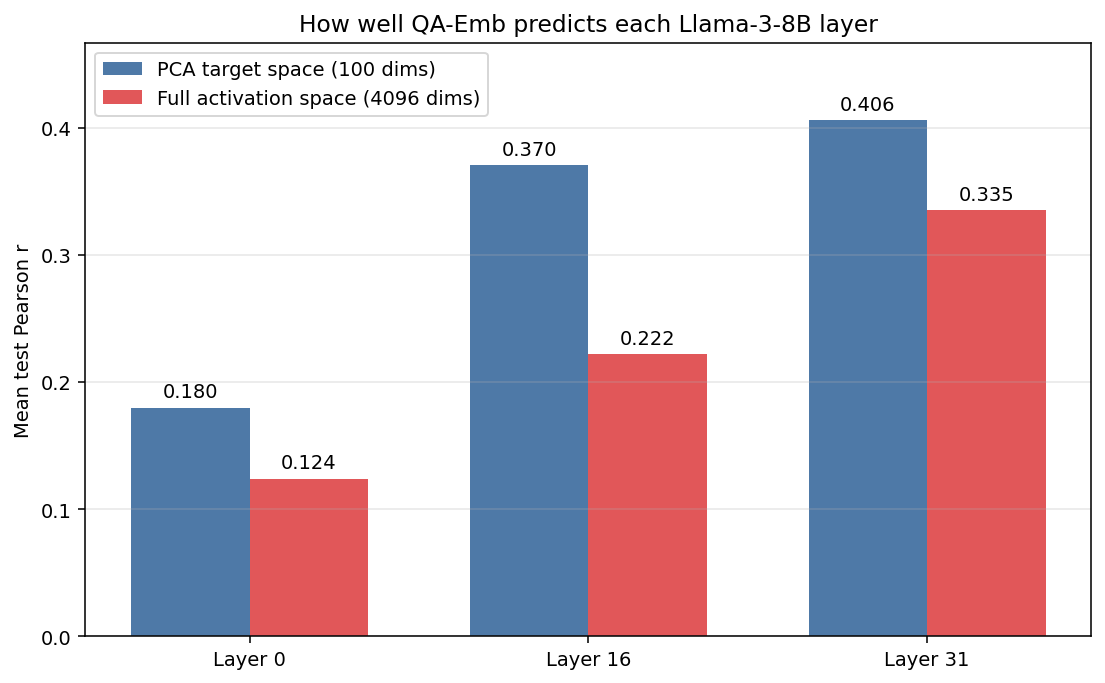

In [13]:
# --- B: Mean correlation per layer, PCA space vs full activation space ---
extra = np.load(os.path.join(CACHE_DIR, 'extra_metrics.npz'))
layer_names = [f'Layer {l}' for l in LAYER_INDICES]
pca_means  = [results[l]['mean_corr'] for l in LAYER_INDICES]
full_means = [float(extra[f'full_mean_corr_layer_{l}']) for l in LAYER_INDICES]

x = np.arange(len(LAYER_INDICES))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, pca_means,  w, label='PCA space (100 dims)',
                color='#4e79a7')
bars2 = ax.bar(x + w/2, full_means, w, label='Full activation space (4096 dims)',
                color='#e15759')
for bars, vals in [(bars1, pca_means), (bars2, full_means)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(layer_names)
ax.set_ylabel('Mean Pearson correlation (test)')
ax.set_title('QA-Emb Predictive Performance by Layer\n(PCA space vs full activation space)')
ax.legend(loc='upper left')
ax.set_ylim(0, max(max(pca_means), max(full_means)) * 1.15)
plt.tight_layout()
plt.show()


In [14]:
# --- C: Top questions by regression weight magnitude ---
for layer_idx in LAYER_INDICES:
    coef = results[layer_idx]['coef']  # shape: (N_PCA_COMPONENTS, 674)
    # Aggregate importance: mean absolute weight across all PCA components
    question_importance = np.mean(np.abs(coef), axis=0)
    top_q_indices = np.argsort(question_importance)[::-1][:10]

    print(f'\n=== Layer {layer_idx}: Top 10 most predictive questions ===')
    for rank, q_idx in enumerate(top_q_indices):
        print(f'  {rank+1}. [{question_importance[q_idx]:.4f}] {QUESTIONS[q_idx]}')



=== Layer 0: Top 10 most predictive questions ===
  1. [0.0043] Does the sentence use a common cliché?
  2. [0.0028] Is the sentence a question?
  3. [0.0024] Does the sentence include a number or statistic?
  4. [0.0023] Is the sentence repetitive or redundant?
  5. [0.0020] Does the sentence include a comparison or simile?
  6. [0.0020] Does the sentence contain a negation?
  7. [0.0020] Does the sentence include a rhetorical question?
  8. [0.0020] Is a specific scientific field or discipline mentioned?
  9. [0.0020] Does the sentence contain a question?
  10. [0.0020] Does the sentence involve mathematical reasoning?

=== Layer 16: Top 10 most predictive questions ===
  1. [0.1792] Does the sentence use a common cliché?
  2. [0.1064] Is the sentence a question?
  3. [0.0616] Is the sentence repetitive or redundant?
  4. [0.0551] Is a specific scientific field or discipline mentioned?
  5. [0.0522] Does the story involve a pet or domestic animal?
  6. [0.0486] Is a natural phenomen

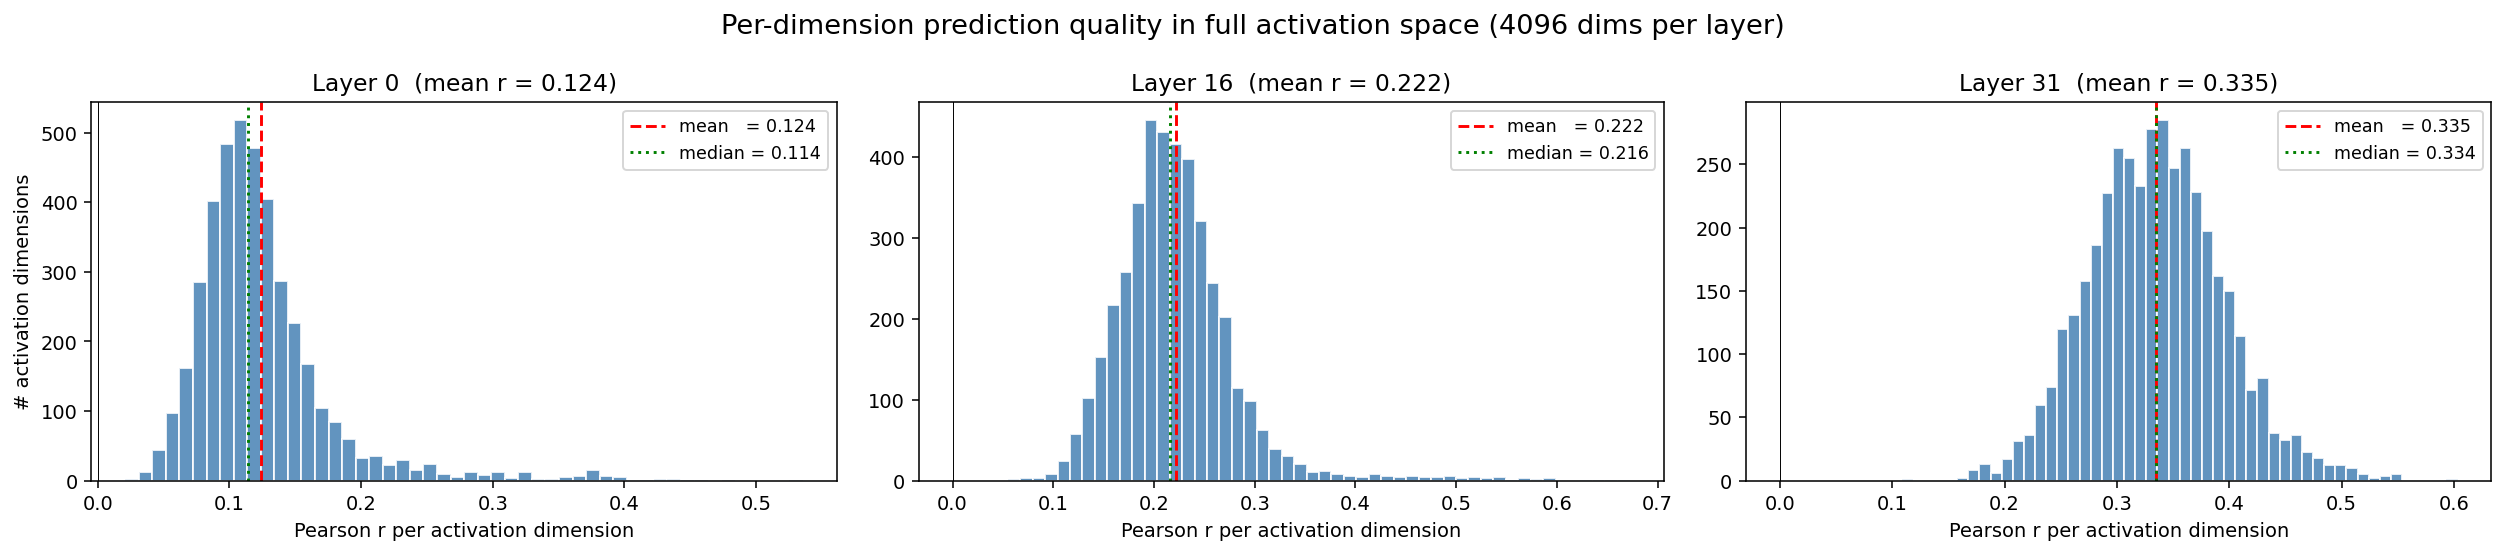

In [15]:
# --- D: Per-dimension correlation in full activation space (4096 dims) ---
# Loads precomputed correlations from extra_metrics.npz (faster than recomputing).

extra = np.load(os.path.join(CACHE_DIR, 'extra_metrics.npz'))

fig, axes = plt.subplots(1, len(LAYER_INDICES), figsize=(18, 4), sharey=True)

for ax_idx, layer_idx in enumerate(LAYER_INDICES):
    dim_corrs = extra[f'full_correlations_layer_{layer_idx}']
    mean_r = float(dim_corrs.mean())
    median_r = float(np.median(dim_corrs))

    axes[ax_idx].hist(dim_corrs, bins=50, color='steelblue', alpha=0.85,
                       edgecolor='white')
    axes[ax_idx].axvline(x=mean_r,   color='red',  linestyle='--',
                          label=f'mean   = {mean_r:.4f}')
    axes[ax_idx].axvline(x=median_r, color='green', linestyle=':',
                          label=f'median = {median_r:.4f}')
    axes[ax_idx].axvline(x=0, color='black', linewidth=0.5)
    axes[ax_idx].set_xlabel('Pearson correlation (test, per 4096-dim activation feature)')
    axes[ax_idx].set_title(f'Layer {layer_idx}  (mean r = {mean_r:.4f})')
    axes[ax_idx].legend(fontsize=9)
    if ax_idx == 0:
        axes[ax_idx].set_ylabel('# activation dimensions (out of 4096)')

plt.suptitle('Per-Dimension Correlation in Full Activation Space', fontsize=14)
plt.tight_layout()
plt.show()


## 11. Feature Selection: How Few Questions Suffice?

Mirroring the paper's finding that 29 questions beat the 985-dim Eng1000 baseline, we test how QA-Emb performance degrades as we use fewer questions (selected by Elastic Net).

In [16]:
from sklearn.linear_model import MultiTaskElasticNet

# Paper spec (Benara et al. 2024, S3): MultiTaskElasticNet (no CV) over 20
# log-spaced alphas in [1e-3, 1], default l1_ratio=0.5. Each alpha gives a
# different number of selected questions; for each, we refit Ridge on the
# selected subset and measure test correlation.


def analyze_layer(ANALYSIS_LAYER):
    cache_path = os.path.join(CACHE_DIR, f'analyze_layer_{ANALYSIS_LAYER}.npz')
    partial_path = os.path.join(CACHE_DIR, f'analyze_layer_{ANALYSIS_LAYER}_partial.npz')

    if os.path.exists(cache_path):
        print(f'Loading cached analyze_layer({ANALYSIS_LAYER}) from {cache_path}')
        cache = np.load(cache_path)
        alphas_path = cache['alphas']
        n_nonzero_arr = cache['n_nonzero']
        perf_arr = cache['perf']
    else:
        Y_train_a = pca_activations[ANALYSIS_LAYER][train_idx]
        Y_test_a = pca_activations[ANALYSIS_LAYER][test_idx]

        alphas_path = np.logspace(0, -3, 20)
        n_alphas = len(alphas_path)

        if os.path.exists(partial_path):
            p = np.load(partial_path, allow_pickle=True)
            done_n = int(p['done'])
            n_nonzero_list = list(p['n_nonzero'][:done_n])
            perf_list = list(p['perf'][:done_n])
            saved_coef = p['enet_coef'] if 'enet_coef' in p.files else None
            saved_intercept = p['enet_intercept'] if 'enet_intercept' in p.files else None
            print(f'Resuming layer {ANALYSIS_LAYER} from alpha index {done_n}/{n_alphas}')
        else:
            done_n = 0
            n_nonzero_list = []
            perf_list = []
            saved_coef = None
            saved_intercept = None

        enet = MultiTaskElasticNet(l1_ratio=0.5, max_iter=2000, tol=1e-3, warm_start=True)
        if saved_coef is not None:
            enet.coef_ = saved_coef
            enet.intercept_ = saved_intercept
            enet.n_iter_ = 0
            enet.n_features_in_ = saved_coef.shape[1]
            enet.dual_gap_ = 0.0

        for i in tqdm(range(done_n, n_alphas), desc=f'Layer {ANALYSIS_LAYER} ENet path'):
            alpha = alphas_path[i]
            enet.alpha = float(alpha)
            enet.fit(X_train, Y_train_a)

            row_norms = np.linalg.norm(enet.coef_, axis=0)
            selected_mask = row_norms > 1e-10
            n_selected = int(selected_mask.sum())

            if n_selected == 0:
                n_nonzero_list.append(0)
                perf_list.append(0.0)
            else:
                X_tr_sub = X_train[:, selected_mask]
                X_te_sub = X_test[:, selected_mask]
                ridge_sub = RidgeCV(alphas=ALPHAS)
                ridge_sub.fit(X_tr_sub, Y_train_a)
                Y_pred_sub = ridge_sub.predict(X_te_sub)

                corrs_sub = []
                for comp in range(N_PCA_COMPONENTS):
                    if np.std(Y_test_a[:, comp]) > 1e-10 and np.std(Y_pred_sub[:, comp]) > 1e-10:
                        r, _ = pearsonr(Y_test_a[:, comp], Y_pred_sub[:, comp])
                        corrs_sub.append(r)
                    else:
                        corrs_sub.append(0.0)
                mean_corr = float(np.mean(corrs_sub))

                n_nonzero_list.append(n_selected)
                perf_list.append(mean_corr)

            done = i + 1
            np.savez(partial_path,
                     done=np.array(done),
                     alphas=alphas_path,
                     n_nonzero=np.array(n_nonzero_list + [0] * (n_alphas - done)),
                     perf=np.array(perf_list + [0.0] * (n_alphas - done)),
                     enet_coef=enet.coef_,
                     enet_intercept=enet.intercept_)

        n_nonzero_arr = np.array(n_nonzero_list)
        perf_arr = np.array(perf_list)
        np.savez(cache_path, alphas=alphas_path, n_nonzero=n_nonzero_arr, perf=perf_arr)
        if os.path.exists(partial_path):
            os.remove(partial_path)
        print(f'Saved analyze_layer({ANALYSIS_LAYER}) to {cache_path}')

    order = np.argsort(n_nonzero_arr)
    nq_sorted = n_nonzero_arr[order]
    perf_sorted = perf_arr[order]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(nq_sorted, perf_sorted, 'o-', color='#4e79a7', markersize=7,
            linewidth=2, label='Mean test r (PCA space, 100 dims)')
    ax.axvline(x=29, color='red', linestyle='--', linewidth=1.5,
               label='29 questions (paper threshold)')
    ax.set_xlabel('# questions selected by ElasticNet (alpha-driven sparsity path)')
    ax.set_ylabel('Mean Pearson correlation (test)')
    ax.set_title(f'ElasticNet sparsity sweep, layer {ANALYSIS_LAYER}\n'
                 'Paper-faithful: each alpha picks a natural subset')
    if nq_sorted.max() > 1:
        ax.set_xscale('symlog', linthresh=1)
    ax.set_xlim(left=-0.5)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('\nPerformance by # selected questions:')
    for nq, perf in zip(nq_sorted, perf_sorted):
        print(f'  {nq:4d} questions: mean r = {perf:.4f}')


## 11b. Top-K (Ridge importance) Sweep — PCA vs Full Activation Space

Complementary view to the ENet sparsity path: rank the 674 questions by their mean absolute Ridge weight, take the top-K, and refit. This lets us evaluate **exactly** K=29 (the paper threshold), and lets us compute the same curve in **full activation space** (per-dim Pearson over 4096 dims) rather than just PCA space.


In [20]:
# Top-K-by-Ridge-importance sweep with both metrics + 29-question marker.
extra = np.load(os.path.join(CACHE_DIR, 'extra_metrics.npz'))
K_values = extra['K_values']

fig, axes = plt.subplots(1, len(LAYER_INDICES), figsize=(18, 5.2), sharey=False)
for ax_idx, layer_idx in enumerate(LAYER_INDICES):
    pca_curve  = extra[f'topK_pca_corr_layer_{layer_idx}']
    full_curve = extra[f'topK_full_corr_layer_{layer_idx}']

    ax = axes[ax_idx]
    ax.plot(K_values, pca_curve,  'o-', color='#4e79a7', markersize=7,
            linewidth=2, label='PCA space (100 dims)')
    ax.plot(K_values, full_curve, 's-', color='#e15759', markersize=7,
            linewidth=2, label='Full activation space (4096 dims)')
    ax.axvline(x=29, color='black', linestyle='--', linewidth=1.5, alpha=0.7,
               label='29 questions (paper)')

    # Mark exact 29-question values
    K_list = K_values.tolist()
    if 29 in K_list:
        i29 = K_list.index(29)
        ax.annotate(f'PCA  r={pca_curve[i29]:.3f}',
                    xy=(29, pca_curve[i29]),
                    xytext=(40, pca_curve[i29] - 0.05),
                    fontsize=9, color='#4e79a7',
                    arrowprops=dict(arrowstyle='->', color='#4e79a7', lw=1))
        ax.annotate(f'Full r={full_curve[i29]:.3f}',
                    xy=(29, full_curve[i29]),
                    xytext=(40, full_curve[i29] + 0.03),
                    fontsize=9, color='#e15759',
                    arrowprops=dict(arrowstyle='->', color='#e15759', lw=1))

    ax.set_xscale('log')
    ax.set_xlabel('# questions (top-K by Ridge importance)')
    if ax_idx == 0:
        ax.set_ylabel('Mean Pearson correlation (test)')
    ax.set_title(f'Layer {layer_idx}')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Performance vs # Questions: top-K by Ridge weight magnitude',
             fontsize=14)
plt.tight_layout()
plt.show()

# Tabular summary
print('\nK     |   layer 0 (PCA / full)   |   layer 16 (PCA / full)   |   layer 31 (PCA / full)')
print('-' * 92)
for i, K in enumerate(K_values):
    parts = [f'{K:4d}  ']
    for layer_idx in LAYER_INDICES:
        p = extra[f'topK_pca_corr_layer_{layer_idx}'][i]
        f_ = extra[f'topK_full_corr_layer_{layer_idx}'][i]
        parts.append(f'|   {p:.4f} / {f_:.4f}    ')
    print(''.join(parts))


## 12. Summary

This notebook tests whether interpretable yes/no question embeddings (QA-Emb) can predict the internal activations of Llama 3-8B, using the **full fMRI story corpus** from the paper for direct comparison with brain results.

**Setup:**
- Same narrative podcast transcripts (OpenNeuro ds003020) as the fMRI paper
- Story-based train/test split (matching the paper's methodology)
- 100 PCA components (matching the paper)
- 674 candidate questions

**Key results to examine:**
- Which layer is most predictable from interpretable questions?
- Do the same questions predict both brain activity AND LLM activations?
- How few questions suffice? (compare with the paper's 29-question result for fMRI)
- Can QA-Emb performance be compared directly with the fMRI paper's Pearson correlations?

**Next steps:**
- Compare QA-Emb predictive power against black-box baselines (e.g., BERT embeddings -> LLaMA activations)
- Generate new questions specifically optimized for predicting LLM activations
- Joint analysis: which questions predict both brain and LLM activations?